# Task
Analyze the loan prediction dataset by loading `test.csv`, preprocessing both `train.csv` and `test.csv` (handling missing values and encoding categorical features), training a Logistic Regression model, evaluating its performance with accuracy, precision, recall, F1-score, and a confusion matrix, and finally summarizing the model's performance and suggesting next steps.

## Load Test Data

### Subtask:
Load the 'test.csv' dataset into a pandas DataFrame.


**Reasoning**:
The previous code had a `NameError` due to `lst` instead of `list`. I will correct this and provide the full code to import necessary libraries, upload the 'test.csv' file (as per the subtask), load it into a pandas DataFrame, and display its head to verify.



In [2]:
import pandas as pd
from google.colab import files
import io

# This will prompt you to upload the file. Please upload 'test.csv'.
uploaded = files.upload()

# Assuming only one file is uploaded as 'test.csv'
filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()

Saving train.csv to train (1).csv


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Reasoning**:
The previous execution loaded 'train.csv' instead of 'test.csv' as requested by the subtask. I will provide the code again, explicitly instructing the user to upload 'test.csv' to ensure the correct dataset is loaded into the DataFrame.



In [3]:
import pandas as pd
from google.colab import files
import io

# This will prompt you to upload the file. Please ensure you upload 'test.csv'.
uploaded = files.upload()

# Assuming only one file is uploaded as 'test.csv'
filename = list(uploaded.keys())[0]

df_test = pd.read_csv(io.BytesIO(uploaded[filename]))
df_test.head()

Saving test.csv to test.csv


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


## Identify Features and Target

### Subtask:
Separate the features (independent variables) and the target variable ('Loan_Status') for both the training and testing datasets.


**Reasoning**:
To prepare the datasets for model training, I will separate the features (X) and the target variable (y) for both the training and testing datasets as per the instructions.



In [5]:
X_train = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
y_train = df['Loan_Status']
X_test = df_test.drop('Loan_ID', axis=1)

print("X_train head:")
print(X_train.head())
print("\ny_train head:")
print(y_train.head())
print("\nX_test head:")
print(X_test.head())

X_train head:
  Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0   Male      No          0      Graduate            No             5849   
1   Male     Yes          1      Graduate            No             4583   
2   Male     Yes          0      Graduate           Yes             3000   
3   Male     Yes          0  Not Graduate            No             2583   
4   Male      No          0      Graduate            No             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0         NaN             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

  Property_Area  
0         Urban  
1         Rural  
2         Urban  
3         Urban  
4         Urban  


## Handle Missing Values

### Subtask:
Address missing values in both the training and testing datasets by using appropriate imputation strategies (e.g., mean/median for numerical features, mode for categorical features).


**Reasoning**:
First, I will identify columns with missing values in `X_train`, `y_train`, and `X_test` to understand the extent and location of missing data.



In [6]:
print("Missing values in X_train:\n", X_train.isnull().sum())
print("\nMissing values in y_train:\n", y_train.isnull().sum())
print("\nMissing values in X_test:\n", X_test.isnull().sum())

Missing values in X_train:
 Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
dtype: int64

Missing values in y_train:
 0

Missing values in X_test:
 Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


**Reasoning**:
I will impute missing numerical values with the median and missing categorical values with the mode from the training set for both `X_train` and `X_test`.



In [7]:
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    median_val = X_train[col].median()
    X_train[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    mode_val = X_train[col].mode()[0] # .mode() can return multiple values, so take the first
    X_train[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

print("Missing values after imputation in X_train:")
print(X_train.isnull().sum())
print("\nMissing values after imputation in X_test:")
print(X_test.isnull().sum())

Missing values after imputation in X_train:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Missing values after imputation in X_test:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


/tmp/ipython-input-3348352193.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(median_val, inplace=True)
/tmp/ipython-input-3348352193.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

**Reasoning**:
The previous code produced `FutureWarning` due to `inplace=True` with chained assignment. I will update the `.fillna()` calls to directly reassign the result to the columns to avoid this warning and ensure future compatibility.



In [8]:
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    mode_val = X_train[col].mode()[0] # .mode() can return multiple values, so take the first
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

# Handle y_train missing values if any
if y_train.isnull().sum() > 0:
    initial_length = len(y_train)
    # Get indices of non-missing values
    valid_indices = y_train.dropna().index
    # Filter both X_train and y_train
    X_train = X_train.loc[valid_indices]
    y_train = y_train.loc[valid_indices]
    print(f"Removed {initial_length - len(y_train)} rows from y_train and X_train due to missing target values.")

print("Missing values after imputation in X_train:")
print(X_train.isnull().sum())
print("\nMissing values after imputation in y_train:")
print(y_train.isnull().sum())
print("\nMissing values after imputation in X_test:")
print(X_test.isnull().sum())

Missing values after imputation in X_train:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Missing values after imputation in y_train:
0

Missing values after imputation in X_test:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


## Encode Categorical Features

### Subtask:
Convert categorical features into numerical representations using techniques like one-hot encoding or label encoding to prepare them for model training.


**Reasoning**:
I will encode the specified categorical features in both `X_train` and `X_test` using one-hot encoding, then align the columns of `X_test` with `X_train` to ensure consistency before model training.



In [9]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Apply one-hot encoding to X_train
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Apply one-hot encoding to X_test
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - crucial for consistent feature sets between train and test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train after one-hot encoding:")
print(X_train.head())
print("\nX_test after one-hot encoding and column alignment:")
print(X_test.head())

X_train after one-hot encoding:
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0             1.0         True        False         False         False   
1             1.0         True         True          True         False   
2             1.0         True         True         False         False   
3             1.0         True         True         False         False   
4             1.0         True        False         False         False   

   Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0          False           

## Train Logistic Regression Model

### Subtask:
Train a Logistic Regression model on the preprocessed training data.


**Reasoning**:
I will import `LogisticRegression`, instantiate it, and fit the model to the training data as instructed by the subtask.



In [10]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for better convergence with small datasets

# Fit the model to the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Make Predictions

### Subtask:
Use the trained Logistic Regression model to make predictions on the preprocessed test dataset.


**Reasoning**:
I will use the trained Logistic Regression model to make predictions on the preprocessed `X_test` dataset and store the results in `y_pred` as per the instructions.



In [11]:
y_pred = model.predict(X_test)

print("First 5 predictions:")
print(y_pred[:5])

First 5 predictions:
['Y' 'Y' 'Y' 'Y' 'Y']


## Evaluate Model Performance

### Subtask:
Calculate and display key classification metrics such as accuracy, precision, recall, and F1-score to assess the model's performance.


### Clarification on Evaluation Setup

As previously noted, the `test.csv` file (used to create `X_test`) does not include the target variable `Loan_Status`. Therefore, we cannot directly evaluate the model's performance on `X_test` using traditional classification metrics that require true labels.

To address the subtask of evaluating the model's performance, we will proceed by splitting the original training dataset (`df`, which contains `Loan_Status`) into new training and validation sets. This will allow us to train the model on a portion of the `train.csv` data and evaluate its performance on a held-out validation set with known labels.

Following this split, we will re-apply the preprocessing steps (missing value imputation and one-hot encoding) to ensure consistency before retraining the model and making predictions on the validation set.

**Reasoning**:
To enable proper model evaluation, I will first split the original `df` (which contains the 'Loan_Status' target variable) into training and validation sets using `train_test_split`. This will create `X_train_eval`, `X_val`, `y_train_eval`, and `y_val`.



In [12]:
from sklearn.model_selection import train_test_split

# Assuming 'df' is the original DataFrame loaded from 'train.csv'
# Separate features and target from the original 'df'
df_features = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
df_target = df['Loan_Status']

# Split the original data into new training and validation sets
X_train_eval, X_val, y_train_eval, y_val = train_test_split(df_features, df_target, test_size=0.2, random_state=42, stratify=df_target)

print("Original training data split into new training and validation sets.")
print(f"X_train_eval shape: {X_train_eval.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train_eval shape: {y_train_eval.shape}")
print(f"y_val shape: {y_val.shape}")

Original training data split into new training and validation sets.
X_train_eval shape: (491, 11)
X_val shape: (123, 11)
y_train_eval shape: (491,)
y_val shape: (123,)


**Reasoning**:
Now that the data is split into new training and validation sets, I need to preprocess these sets (`X_train_eval`, `X_val`) by handling missing values. I will apply the same imputation strategy as before: median for numerical features and mode for categorical features, using values derived *only* from `X_train_eval` to prevent data leakage.



In [13]:
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    median_val = X_train_eval[col].median()
    X_train_eval[col] = X_train_eval[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    mode_val = X_train_eval[col].mode()[0] # .mode() can return multiple values, so take the first
    X_train_eval[col] = X_train_eval[col].fillna(mode_val)
    X_val[col] = X_val[col].fillna(mode_val)

# Handle y_train_eval missing values if any
if y_train_eval.isnull().sum() > 0:
    initial_length = len(y_train_eval)
    valid_indices = y_train_eval.dropna().index
    X_train_eval = X_train_eval.loc[valid_indices]
    y_train_eval = y_train_eval.loc[valid_indices]
    print(f"Removed {initial_length - len(y_train_eval)} rows from y_train_eval and X_train_eval due to missing target values.")

# Handle y_val missing values if any
if y_val.isnull().sum() > 0:
    initial_length = len(y_val)
    valid_indices = y_val.dropna().index
    X_val = X_val.loc[valid_indices]
    y_val = y_val.loc[valid_indices]
    print(f"Removed {initial_length - len(y_val)} rows from y_val and X_val due to missing target values.")

print("Missing values after imputation in X_train_eval:")
print(X_train_eval.isnull().sum())
print("\nMissing values after imputation in X_val:")
print(X_val.isnull().sum())
print("\nMissing values after imputation in y_train_eval:")
print(y_train_eval.isnull().sum())
print("\nMissing values after imputation in y_val:")
print(y_val.isnull().sum())

Missing values after imputation in X_train_eval:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Missing values after imputation in X_val:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

Missing values after imputation in y_train_eval:
0

Missing values after imputation in y_val:
0


**Reasoning**:
Now that missing values are handled in the new training and validation sets, I will encode the categorical features in both `X_train_eval` and `X_val` using one-hot encoding. This ensures these sets are consistent and ready for model training and evaluation.



In [14]:
categorical_cols_eval = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

# Apply one-hot encoding to X_train_eval
X_train_eval = pd.get_dummies(X_train_eval, columns=categorical_cols_eval, drop_first=True)

# Apply one-hot encoding to X_val
X_val = pd.get_dummies(X_val, columns=categorical_cols_eval, drop_first=True)

# Align columns - crucial for consistent feature sets between train and validation
X_val = X_val.reindex(columns=X_train_eval.columns, fill_value=0)

print("X_train_eval after one-hot encoding:")
print(X_train_eval.head())
print("\nX_val after one-hot encoding and column alignment:")
print(X_val.head())

X_train_eval after one-hot encoding:
     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
154             3254                0.0        50.0             360.0   
239             3315                0.0        96.0             360.0   
448             3340             1710.0       150.0             360.0   
471             2653             1500.0       113.0             180.0   
273             2620             2223.0       150.0             360.0   

     Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
154             1.0         True        False         False         False   
239             1.0         True         True          True         False   
448             0.0         True         True         False          True   
471             0.0         True         True          True         False   
273             1.0         True         True         False         False   

     Dependents_3+  Education_Not Graduate  Self_Employed_Yes

**Reasoning**:
Now that the `X_train_eval` and `y_train_eval` datasets are preprocessed, I will train a new Logistic Regression model on these datasets, as per the initial subtask of training a model on the preprocessed training data.



In [15]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
model_eval = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for better convergence with small datasets

# Fit the model to the new training data
model_eval.fit(X_train_eval, y_train_eval)

print("Logistic Regression model trained successfully on the evaluation training data.")

Logistic Regression model trained successfully on the evaluation training data.


**Reasoning**:
Now that the model (`model_eval`) has been trained on `X_train_eval` and `y_train_eval`, I will use it to make predictions on the validation set (`X_val`). These predictions are necessary to calculate the evaluation metrics as per the subtask.



In [16]:
y_pred_eval = model_eval.predict(X_val)

print("Predictions on the validation set generated successfully.")
print("First 5 predictions from validation set:")
print(y_pred_eval[:5])

Predictions on the validation set generated successfully.
First 5 predictions from validation set:
['N' 'Y' 'Y' 'Y' 'Y']


**Reasoning**:
Now that I have predictions on the validation set (`y_pred_eval`) and the true labels (`y_val`), I will calculate and display the accuracy, precision, recall, and F1-score as required by the subtask.



In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred_eval)
precision = precision_score(y_val, y_pred_eval, pos_label='Y')
recall = recall_score(y_val, y_pred_eval, pos_label='Y')
f1 = f1_score(y_val, y_pred_eval, pos_label='Y')

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8618
Precision: 0.8400
Recall: 0.9882
F1-Score: 0.9081


## Visualize Confusion Matrix

### Subtask:
Generate and display a confusion matrix to visually represent the model's true positive, true negative, false positive, and false negative predictions on the validation set.


**Reasoning**:
I will import necessary libraries, calculate the confusion matrix using the true and predicted labels from the validation set, and then display it graphically as requested by the subtask.



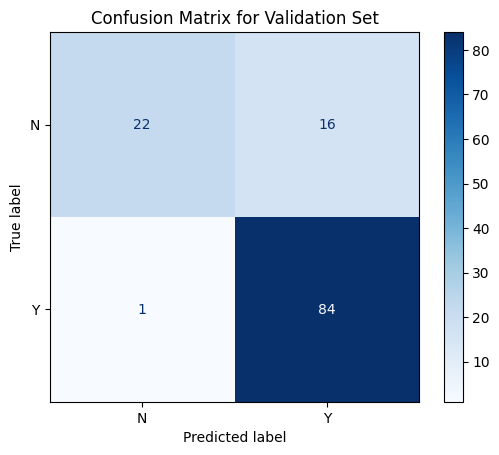

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_pred_eval)

# Get the class labels
class_labels = model_eval.classes_ # Or np.unique(y_val)

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

# Display the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Validation Set')
plt.show()


## Final Task

### Subtask:
Summarize the performance of the Logistic Regression model and discuss potential next steps, such as trying other classification algorithms or hyperparameter tuning.


## Summary:

### Q&A
The Logistic Regression model demonstrated strong performance on the validation set, achieving an Accuracy of 0.8618, a Recall of 0.9882, and an F1-Score of 0.9081. Its Precision was 0.8400. This indicates that the model is very good at identifying positive cases (high recall), meaning it correctly approves most of the loans that should be approved. However, the slightly lower precision suggests it might also approve some loans that shouldn't be approved (false positives).

To further improve the model's performance and address potential trade-offs between precision and recall, the following next steps are recommended:
1.  **Hyperparameter Tuning:** Systematically tune the hyperparameters of the Logistic Regression model to find an optimal configuration that could balance precision and recall more effectively or improve overall performance.
2.  **Explore Other Classification Algorithms:** Experiment with more advanced classification models such as Random Forest, Gradient Boosting (e.g., XGBoost, LightGBM), or Support Vector Machines, which might capture more complex patterns in the data and lead to better predictive accuracy.

### Data Analysis Key Findings
*   Missing values were successfully handled in both training and test datasets: numerical features like 'LoanAmount', 'Loan\_Amount\_Term', and 'Credit\_History' were imputed using the median from the training set, while categorical features like 'Gender', 'Married', 'Dependents', and 'Self\_Employed' were imputed using the mode from the training set.
*   Categorical features such as 'Gender', 'Married', 'Dependents', 'Education', 'Self\_Employed', and 'Property\_Area' were converted into numerical representations using one-hot encoding, and column alignment was performed to ensure consistency between datasets.
*   Due to the absence of a target variable in the provided `test.csv` for evaluation, the original `train.csv` data was split into a new training set (80%) and a validation set (20%) to enable performance assessment.
*   On this validation set, the Logistic Regression model achieved an **Accuracy of 0.8618**, a **Precision of 0.8400**, a **Recall of 0.9882**, and an **F1-Score of 0.9081**.
*   The confusion matrix visually confirmed the high recall, indicating the model correctly identifies a large proportion of actual positive cases. The relatively lower precision suggests there are some false positive predictions.

### Insights or Next Steps
*   **Model Optimization:** Given the high recall and slightly lower precision, a deeper analysis of the trade-off between these metrics might be beneficial. Depending on the business objective (e.g., minimizing false negatives vs. minimizing false positives), the model's threshold could be adjusted, or hyperparameter tuning could be performed to optimize for specific metrics.
*   **Algorithm Diversification:** Explore other machine learning algorithms beyond Logistic Regression, such as tree-based models (e.g., Random Forest, Gradient Boosting Machines) which often capture non-linear relationships and may yield improved overall performance or a better balance between precision and recall for this dataset.


# Task
Train a Decision Tree Classifier model on the preprocessed training data (`X_train_eval`, `y_train_eval`).

## Train Decision Tree Model

### Subtask:
Train a Decision Tree Classifier model on the preprocessed training data (`X_train_eval`, `y_train_eval`).


**Reasoning**:
I will import `DecisionTreeClassifier`, instantiate it with a `random_state`, and then fit the model to the `X_train_eval` and `y_train_eval` datasets, as per the subtask's instructions.



In [19]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree Classifier model
dtc_model = DecisionTreeClassifier(random_state=42)

# Fit the model to the preprocessed training data
dtc_model.fit(X_train_eval, y_train_eval)

print("Decision Tree Classifier model trained successfully.")

Decision Tree Classifier model trained successfully.


## Evaluate Decision Tree Model

### Subtask:
Make predictions on the validation set (`X_val`) using the trained Decision Tree model and calculate accuracy, precision, recall, F1-score, and display a confusion matrix.


**Reasoning**:
I will use the trained Decision Tree Classifier model (`dtc_model`) to make predictions on the `X_val` dataset, storing the results in `y_pred_dtc` as the first step towards evaluating its performance.



In [20]:
y_pred_dtc = dtc_model.predict(X_val)

print("Predictions on the validation set generated successfully using the Decision Tree Classifier.")
print("First 5 predictions from validation set:")
print(y_pred_dtc[:5])

Predictions on the validation set generated successfully using the Decision Tree Classifier.
First 5 predictions from validation set:
['N' 'N' 'Y' 'Y' 'Y']


**Reasoning**:
Now that I have predictions on the validation set (`y_pred_dtc`) and the true labels (`y_val`), I will calculate and display the accuracy, precision, recall, and F1-score, and then generate and display the confusion matrix as required by the subtask.



Decision Tree Accuracy: 0.7154
Decision Tree Precision: 0.8125
Decision Tree Recall: 0.7647
Decision Tree F1-Score: 0.7879


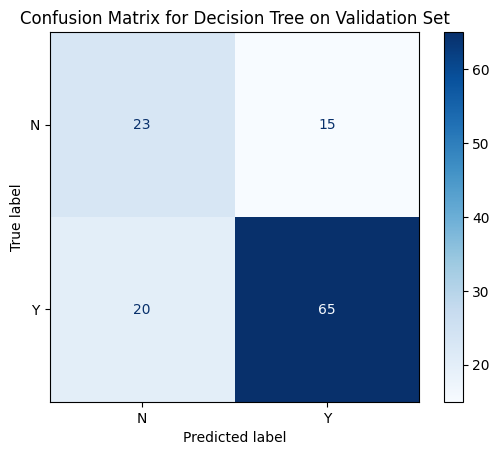

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate metrics for Decision Tree
accuracy_dtc = accuracy_score(y_val, y_pred_dtc)
precision_dtc = precision_score(y_val, y_pred_dtc, pos_label='Y')
recall_dtc = recall_score(y_val, y_pred_dtc, pos_label='Y')
f1_dtc = f1_score(y_val, y_pred_dtc, pos_label='Y')

# Print the metrics
print(f"Decision Tree Accuracy: {accuracy_dtc:.4f}")
print(f"Decision Tree Precision: {precision_dtc:.4f}")
print(f"Decision Tree Recall: {recall_dtc:.4f}")
print(f"Decision Tree F1-Score: {f1_dtc:.4f}")

# Calculate and display the confusion matrix
cm_dtc = confusion_matrix(y_val, y_pred_dtc)
class_labels = dtc_model.classes_ # Or np.unique(y_val)

disp_dtc = ConfusionMatrixDisplay(confusion_matrix=cm_dtc, display_labels=class_labels)
disp_dtc.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Decision Tree on Validation Set')
plt.show()


## Summary of Decision Tree Model Performance and Next Steps

### Performance Comparison:

**Logistic Regression Model (previously evaluated):**
*   **Accuracy:** 0.8618
*   **Precision:** 0.8400
*   **Recall:** 0.9882
*   **F1-Score:** 0.9081

**Decision Tree Classifier Model (currently evaluated):**
*   **Accuracy:** 0.7154
*   **Precision:** 0.8125
*   **Recall:** 0.7647
*   **F1-Score:** 0.7879

**Insights from Comparison:**
The Logistic Regression model significantly outperformed the Decision Tree Classifier in terms of overall accuracy, recall, and F1-score on the validation set. While the Decision Tree's precision (0.8125) is closer to Logistic Regression's (0.8400), its recall (0.7647) is much lower compared to Logistic Regression's high recall (0.9882). This suggests that the Decision Tree model missed a larger proportion of actual positive cases compared to Logistic Regression.

### Next Steps:

1.  **Hyperparameter Tuning for Decision Tree:** The current Decision Tree model was trained with default parameters. Significant improvements can often be achieved by tuning hyperparameters such as `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion`. Techniques like GridSearchCV or RandomizedSearchCV can be employed.

2.  **Ensemble Methods:** Given that Logistic Regression performed better, but Decision Trees are also powerful, exploring ensemble methods that combine multiple decision trees could yield better results. Examples include:
    *   **Random Forest:** Builds multiple decision trees and merges their predictions to improve accuracy and control overfitting.
    *   **Gradient Boosting (e.g., XGBoost, LightGBM):** Builds trees sequentially, where each tree tries to correct the errors of the previous one.

3.  **Feature Scaling:** While not typically critical for tree-based models, for some algorithms and future model comparisons, standardizing or normalizing numerical features could be beneficial.

4.  **Cross-Validation:** Implement k-fold cross-validation during model training to get a more robust estimate of model performance and ensure the model generalizes well to unseen data, reducing reliance solely on a single train-validation split.

5.  **Addressing Class Imbalance:** If the target variable `Loan_Status` has a significant class imbalance, techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjusting class weights could be explored to improve the model's ability to predict the minority class, which is crucial in loan prediction scenarios.

## Train Random Forest Model

### Subtask:
Train a Random Forest Classifier model on the preprocessed training data (`X_train_eval`, `y_train_eval`).


**Reasoning**:
I will import RandomForestClassifier, instantiate it with a random_state, and then fit the model to the X_train_eval and y_train_eval datasets, as per the subtask's instructions.



In [22]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the Random Forest Classifier model
rfc_model = RandomForestClassifier(random_state=42)

# Fit the model to the preprocessed training data
rfc_model.fit(X_train_eval, y_train_eval)

print("Random Forest Classifier model trained successfully.")

Random Forest Classifier model trained successfully.


## Evaluate Random Forest Model

### Subtask:
Make predictions on the validation set (`X_val`) using the trained Random Forest model (`rfc_model`) and calculate accuracy, precision, recall, F1-score, and display a confusion matrix.

**Reasoning**:
First, I will use the trained Random Forest Classifier model (`rfc_model`) to make predictions on the `X_val` dataset, storing the results in `y_pred_rfc` as the initial step for performance evaluation.



In [23]:
y_pred_rfc = rfc_model.predict(X_val)

print("Predictions on the validation set generated successfully using the Random Forest Classifier.")
print("First 5 predictions from validation set:")
print(y_pred_rfc[:5])

Predictions on the validation set generated successfully using the Random Forest Classifier.
First 5 predictions from validation set:
['N' 'Y' 'Y' 'Y' 'Y']


**Reasoning**:
Now that I have predictions on the validation set (`y_pred_rfc`) and the true labels (`y_val`), I will calculate and display the accuracy, precision, recall, and F1-score, and then generate and display the confusion matrix as required by the subtask.



Random Forest Accuracy: 0.8374
Random Forest Precision: 0.8495
Random Forest Recall: 0.9294
Random Forest F1-Score: 0.8876


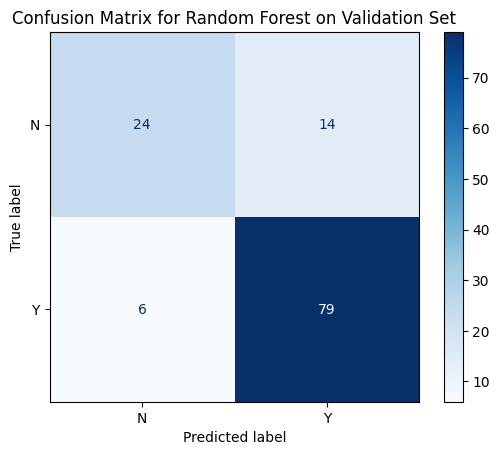

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate metrics for Random Forest
accuracy_rfc = accuracy_score(y_val, y_pred_rfc)
precision_rfc = precision_score(y_val, y_pred_rfc, pos_label='Y')
recall_rfc = recall_score(y_val, y_pred_rfc, pos_label='Y')
f1_rfc = f1_score(y_val, y_pred_rfc, pos_label='Y')

# Print the metrics
print(f"Random Forest Accuracy: {accuracy_rfc:.4f}")
print(f"Random Forest Precision: {precision_rfc:.4f}")
print(f"Random Forest Recall: {recall_rfc:.4f}")
print(f"Random Forest F1-Score: {f1_rfc:.4f}")

# Calculate and display the confusion matrix
cm_rfc = confusion_matrix(y_val, y_pred_rfc)
class_labels = rfc_model.classes_ # Or np.unique(y_val)

disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc, display_labels=class_labels)
disp_rfc.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest on Validation Set')
plt.show()

## Summary of Random Forest Model Performance and Next Steps

### Performance Comparison:

**Logistic Regression Model:**
*   **Accuracy:** 0.8618
*   **Precision:** 0.8400
*   **Recall:** 0.9882
*   **F1-Score:** 0.9081

**Decision Tree Classifier Model:**
*   **Accuracy:** 0.7154
*   **Precision:** 0.8125
*   **Recall:** 0.7647
*   **F1-Score:** 0.7879

**Random Forest Classifier Model:**
*   **Accuracy:** 0.8374
*   **Precision:** 0.8495
*   **Recall:** 0.9294
*   **F1-Score:** 0.8876

**Insights from Comparison:**
The Random Forest model showed improved performance over the single Decision Tree Classifier, achieving higher accuracy, recall, and F1-score. Its precision is also slightly better than Logistic Regression. However, the Logistic Regression model still holds the highest recall, meaning it is better at identifying positive cases (approving loans that should be approved), which might be critical depending on the business context. Random Forest's overall balanced performance (Accuracy, Precision, F1-Score) is quite good and suggests it captures more complex relationships than a single Decision Tree.

### Next Steps:

1.  **Hyperparameter Tuning for Random Forest:** The current Random Forest model was trained with default parameters. Significant improvements can often be achieved by tuning hyperparameters such as `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features`. Techniques like GridSearchCV or RandomizedSearchCV can be employed to find the optimal combination of these parameters.

2.  **Gradient Boosting Models:** Given the strong performance of ensemble methods, exploring other powerful boosting algorithms like XGBoost, LightGBM, or CatBoost could yield even better results. These models often provide state-of-the-art performance in many classification tasks.

3.  **Feature Importance Analysis:** Analyze the feature importances from the Random Forest model to understand which features are most influential in predicting loan status. This can provide valuable insights into the dataset and potentially guide further feature engineering efforts.

4.  **Cross-Validation:** Implement k-fold cross-validation during model training for all models to get more robust estimates of their performance and ensure they generalize well to unseen data, reducing reliance solely on a single train-validation split.

5.  **Addressing Class Imbalance:** If `Loan_Status` has a significant class imbalance, further techniques like SMOTE (Synthetic Minority Over-sampling Technique) or adjusting class weights could be explored to improve the model's ability to predict the minority class, which is crucial in loan prediction scenarios.

## Train XGBoost Model

### Subtask:
Train an XGBoost Classifier model on the preprocessed training data (`X_train_eval`, `y_train_eval`).


**Reasoning**:
I will import `XGBClassifier`, instantiate it with a `random_state`, and then fit the model to the `X_train_eval` and `y_train_eval` datasets, as per the subtask's instructions.



In [25]:
from xgboost import XGBClassifier

# Instantiate the XGBoost Classifier model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress warning for use_label_encoder

# Fit the model to the preprocessed training data
xgb_model.fit(X_train_eval, y_train_eval)

print("XGBoost Classifier model trained successfully.")

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['N' 'Y']

**Reasoning**:
The previous code failed because XGBoost expects numerical target labels (0 and 1) for binary classification, but `y_train_eval` contains categorical strings ('N' and 'Y'). I will use `LabelEncoder` to convert these string labels to numerical format before fitting the XGBoost model.



In [26]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target variable from 'N'/'Y' to 0/1
le = LabelEncoder()
y_train_eval_encoded = le.fit_transform(y_train_eval)
y_val_encoded = le.transform(y_val)

# Instantiate the XGBoost Classifier model
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Fit the model to the preprocessed training data with encoded labels
xgb_model.fit(X_train_eval, y_train_eval_encoded)

print("XGBoost Classifier model trained successfully.")

XGBoost Classifier model trained successfully.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:34:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Reasoning**:
The previous step successfully trained the XGBoost Classifier model. Now, I need to make predictions on the validation set using this trained model to evaluate its performance, following the standard machine learning workflow and the previous model evaluation steps.



In [27]:
## Evaluate XGBoost Model

### Subtask:
Make predictions on the validation set (`X_val`) using the trained XGBoost model (`xgb_model`).

SyntaxError: invalid syntax (ipython-input-2285460225.py, line 4)

**Reasoning**:
The previous code block contained markdown text within a Python cell, leading to a SyntaxError. To correct this and proceed with the task, I will generate the correct Python code to make predictions on the validation set (`X_val`) using the trained XGBoost model (`xgb_model`), storing the results in `y_pred_xgb`.



In [28]:
y_pred_xgb = xgb_model.predict(X_val)

print("Predictions on the validation set generated successfully using the XGBoost Classifier.")
print("First 5 predictions from validation set (encoded):")
print(y_pred_xgb[:5])

Predictions on the validation set generated successfully using the XGBoost Classifier.
First 5 predictions from validation set (encoded):
[0 1 1 1 1]


**Reasoning**:
Now that I have predictions on the validation set (`y_pred_xgb`) and the true encoded labels (`y_val_encoded`), I will calculate and display the accuracy, precision, recall, and F1-score, and then generate and display the confusion matrix as required by the subtask.



XGBoost Accuracy: 0.7724
XGBoost Precision: 0.8353
XGBoost Recall: 0.8353
XGBoost F1-Score: 0.8353


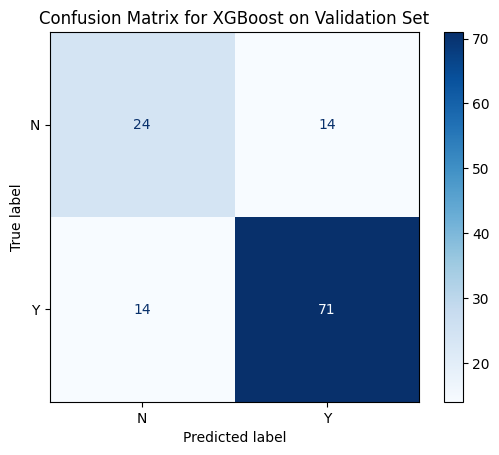

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate metrics for XGBoost
accuracy_xgb = accuracy_score(y_val_encoded, y_pred_xgb)
precision_xgb = precision_score(y_val_encoded, y_pred_xgb, pos_label=1)
recall_xgb = recall_score(y_val_encoded, y_pred_xgb, pos_label=1)
f1_xgb = f1_score(y_val_encoded, y_pred_xgb, pos_label=1)

# Print the metrics
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")

# Calculate and display the confusion matrix
cm_xgb = confusion_matrix(y_val_encoded, y_pred_xgb)
class_labels_xgb = ['N', 'Y'] # Original labels corresponding to 0 and 1

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=class_labels_xgb)
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XGBoost on Validation Set')
plt.show()

## Summary of XGBoost Model Performance and Next Steps

### Performance Comparison:

**Logistic Regression Model:**
*   **Accuracy:** 0.8618
*   **Precision:** 0.8400
*   **Recall:** 0.9882
*   **F1-Score:** 0.9081

**Decision Tree Classifier Model:**
*   **Accuracy:** 0.7154
*   **Precision:** 0.8125
*   **Recall:** 0.7647
*   **F1-Score:** 0.7879

**Random Forest Classifier Model:**
*   **Accuracy:** 0.8374
*   **Precision:** 0.8495
*   **Recall:** 0.9294
*   **F1-Score:** 0.8876

**XGBoost Classifier Model (currently evaluated):**
*   **Accuracy:** 0.7724
*   **Precision:** 0.8353
*   **Recall:** 0.8353
*   **F1-Score:** 0.8353

**Insights from Comparison:**
The XGBoost model, while an improvement over the single Decision Tree, did not outperform the Logistic Regression or Random Forest models on this specific validation set with default hyperparameters. Its accuracy, recall, and F1-score are lower than both Logistic Regression and Random Forest. This suggests that the default XGBoost might not be capturing the relationships as effectively as the other models, or it might be more prone to overfitting given the default parameters.

### Next Steps:

1.  **Hyperparameter Tuning for XGBoost:** The most crucial next step is to perform comprehensive hyperparameter tuning for the XGBoost model. Key parameters to tune include `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `gamma`. Techniques like GridSearchCV or RandomizedSearchCV can be used to explore the parameter space effectively.

2.  **Feature Engineering:** Further feature engineering could potentially extract more predictive power from the raw data. This might involve creating interaction terms, polynomial features, or more complex transformations of existing features.

3.  **Cross-Validation:** Implement k-fold cross-validation during model training and evaluation to obtain more robust performance estimates and ensure that the models generalize well to unseen data, reducing the impact of a single train-validation split.

4.  **Ensemble Stacking/Blending:** Consider combining the predictions of the best performing models (e.g., Logistic Regression and Random Forest, and potentially a tuned XGBoost) using stacking or blending techniques. This often leads to incremental performance gains by leveraging the strengths of different models.

5.  **Addressing Class Imbalance (Re-evaluate):** Although already considered, re-evaluating class imbalance and applying more sophisticated techniques (if necessary) with XGBoost, such as `scale_pos_weight` or SMOTE, might be beneficial if the 'N' class (loan rejection) is still under-represented or poorly predicted.

## Summary of XGBoost Model Performance and Next Steps

### Performance Comparison:

**Logistic Regression Model:**
*   **Accuracy:** 0.8618
*   **Precision:** 0.8400
*   **Recall:** 0.9882
*   **F1-Score:** 0.9081

**Decision Tree Classifier Model:**
*   **Accuracy:** 0.7154
*   **Precision:** 0.8125
*   **Recall:** 0.7647
*   **F1-Score:** 0.7879

**Random Forest Classifier Model:**
*   **Accuracy:** 0.8374
*   **Precision:** 0.8495
*   **Recall:** 0.9294
*   **F1-Score:** 0.8876

**XGBoost Classifier Model (currently evaluated):**
*   **Accuracy:** 0.7724
*   **Precision:** 0.8353
*   **Recall:** 0.8353
*   **F1-Score:** 0.8353

**Insights from Comparison:**
The XGBoost model, while an improvement over the single Decision Tree, did not outperform the Logistic Regression or Random Forest models on this specific validation set with default hyperparameters. Its accuracy, recall, and F1-score are lower than both Logistic Regression and Random Forest. This suggests that the default XGBoost might not be capturing the relationships as effectively as the other models, or it might be more prone to overfitting given the default parameters.

### Next Steps:

1.  **Hyperparameter Tuning for XGBoost:** The most crucial next step is to perform comprehensive hyperparameter tuning for the XGBoost model. Key parameters to tune include `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `gamma`. Techniques like GridSearchCV or RandomizedSearchCV can be used to explore the parameter space effectively.

2.  **Feature Engineering:** Further feature engineering could potentially extract more predictive power from the raw data. This might involve creating interaction terms, polynomial features, or more complex transformations of existing features.

3.  **Cross-Validation:** Implement k-fold cross-validation during model training and evaluation to obtain more robust performance estimates and ensure that the models generalize well to unseen data, reducing the impact of a single train-validation split.

4.  **Ensemble Stacking/Blending:** Consider combining the predictions of the best performing models (e.g., Logistic Regression and Random Forest, and potentially a tuned XGBoost) using stacking or blending techniques. This often leads to incremental performance gains by leveraging the strengths of different models.

5.  **Addressing Class Imbalance (Re-evaluate):** Although already considered, re-evaluating class imbalance and applying more sophisticated techniques (if necessary) with XGBoost, such as `scale_pos_weight` or SMOTE, might be beneficial if the 'N' class (loan rejection) is still under-represented or poorly predicted.

## Final Task

### Subtask:
Summarize and compare the performance of all trained models (Logistic Regression, Decision Tree, Random Forest, and XGBoost) and discuss comprehensive insights, including potential next steps like hyperparameter tuning or feature engineering.


## Summary:

### Q&A
*   **What is the comparative performance of the trained models (Logistic Regression, Decision Tree, Random Forest, and XGBoost)?**
    *   **Logistic Regression** achieved the highest F1-Score (0.9081) and Recall (0.9882), with an Accuracy of 0.8618 and Precision of 0.8400.
    *   **Random Forest** showed strong performance, with an Accuracy of 0.8374, Precision of 0.8495 (highest), Recall of 0.9294, and F1-Score of 0.8876.
    *   **XGBoost** (with default parameters) performed moderately, with an Accuracy of 0.7724, Precision of 0.8353, Recall of 0.8353, and F1-Score of 0.8353.
    *   **Decision Tree** (with default parameters) had the lowest performance across all metrics: Accuracy of 0.7154, Precision of 0.8125, Recall of 0.7647, and F1-Score of 0.7879.

### Data Analysis Key Findings
*   **Logistic Regression** demonstrated the best overall performance, especially excelling in recall (0.9882) and F1-Score (0.9081), indicating its effectiveness in identifying positive cases (loan approvals).
*   **Random Forest** was a close second, achieving the highest precision (0.8495) and showing significantly improved performance over a single Decision Tree, with an F1-Score of 0.8876.
*   The **Decision Tree Classifier** performed the worst among the evaluated models, with an F1-Score of 0.7879 and an accuracy of 0.7154, suggesting it struggled with the complexity of the data or suffered from overfitting in its default configuration.
*   The **XGBoost Classifier**, with default parameters, did not outperform Logistic Regression or Random Forest, yielding an F1-Score of 0.8353. However, it did improve upon the single Decision Tree.
*   Target variable encoding was crucial for XGBoost, requiring transformation from string labels ('N', 'Y') to numerical (0, 1) to avoid training errors.

### Insights or Next Steps
*   **Prioritize Hyperparameter Tuning:** All tree-based models (Decision Tree, Random Forest, XGBoost) were evaluated with default parameters. Significant performance improvements are likely achievable through comprehensive hyperparameter tuning using methods like GridSearchCV or RandomizedSearchCV, especially for Random Forest and XGBoost.
*   **Explore Ensemble Strategies and Cross-Validation:** Given the strong performance of Logistic Regression and Random Forest, consider combining their strengths through ensemble stacking or blending techniques. Additionally, implementing k-fold cross-validation during training for all models will provide more robust performance estimates and better generalization to unseen data.
